In [1]:
# Import library to work with Bigquery and using pandas

from google.colab import auth
from google.cloud import bigquery
import pandas as pd

In [2]:
# Get authenticate to work with third party (Bigquery)

auth.authenticate_user()
print("Authenticated")

Authenticated


In [3]:
# Set project name from Bigquery

project_id = 'nantipat-olist-project'
client = bigquery.Client(project = project_id)

In [4]:
# Query to get data, change it to dataframe, and check head to see data.

query = f"""
    SELECT * FROM `{project_id}.olist_cleaned.master_orders`
"""

df = client.query(query).to_dataframe()

df.head()

,order_id,customer_id,order_status,purchase_at,delivered_at,customer_city,customer_state,product_category_name,price,freight_value,delivery_time_days
0,807756ebd577f025334944b87da7dbc3,5e9e1ae42e02df93e9a591e86fd531a3,delivered,2017-11-23 16:47:19+00:00,2017-11-30 20:58:33+00:00,abaete,MG,None,36.90,13.37,7
1,21bce62cff4eacc6c074129488939291,c435a68d2db4803b48e6b075ba4b15a7,delivered,2018-03-22 09:43:16+00:00,2018-04-24 00:17:41+00:00,acarau,CE,None,122.99,37.55,33
2,ea7835f19dc6af291955d6e270d443f4,d5c70e33b26d11965027895a8e8cb748,delivered,2017-10-26 09:49:40+00:00,2017-11-09 15:14:49+00:00,agrestina,PE,None,1989.00,77.34,14
3,c0d11a106cbef6047ce147e9f8aac554,2fea795dd61498e3f5f5b08c56c5565f,delivered,2018-04-09 15:07:56+00:00,2018-04-23 18:21:56+00:00,aguas de santa barbara,SP,None,102.90,23.30,14
4,cfbc27fc3b0b3946a3dea53be0022108,0a84f5dbc13ce8afbc36bcd1b36a99e1,delivered,2018-01-22 12:33:43+00:00,2018-02-26 19:52:49+00:00,aguas lindas de goias,GO,None,150.00,14.80,35


In [5]:
# Check data columns name and check missing value from here again.
# After checked i've found out that it's have one columns that have missing values which is product_category_name.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110189 entries, 0 to 110188
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   order_id               110189 non-null  object             
 1   customer_id            110189 non-null  object             
 2   order_status           110189 non-null  object             
 3   purchase_at            110189 non-null  datetime64[us, UTC]
 4   delivered_at           110189 non-null  datetime64[us, UTC]
 5   customer_city          110189 non-null  object             
 6   customer_state         110189 non-null  object             
 7   product_category_name  108652 non-null  object             
 8   price                  110189 non-null  float64            
 9   freight_value          110189 non-null  float64            
 10  delivery_time_days     110189 non-null  Int64              
dtypes: Int64(1), datetime64[us, UTC](2), fl

In [6]:
# For the numerical variable, i want to check that is it have outliers or not.

df.describe()

,price,freight_value,delivery_time_days
count,110189.000000,110189.000000,110189.0
mean,119.977937,19.948869,12.410576
std,182.304615,15.698615,9.454823
min,0.850000,0.000000,0.0
25%,39.900000,13.080000,7.0
50%,74.900000,16.260000,10.0
75%,134.170000,21.150000,16.0
max,6735.000000,409.680000,210.0


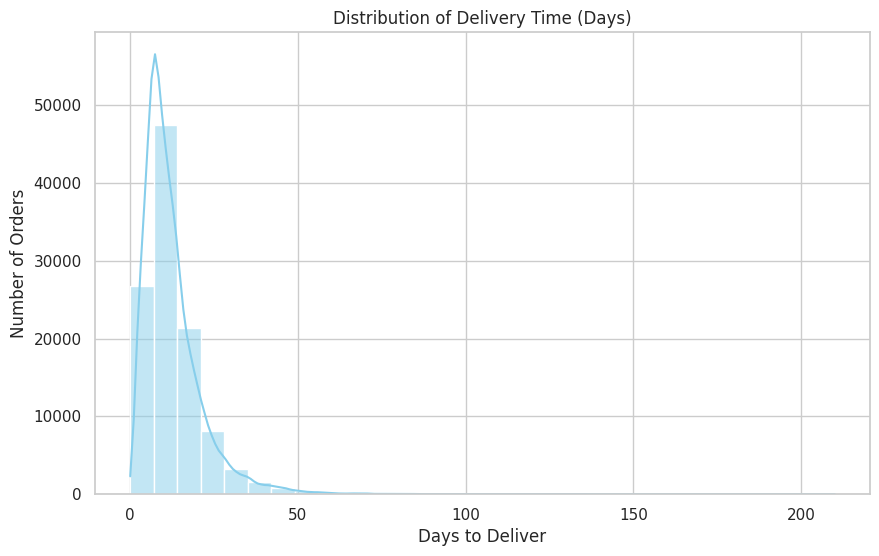

In [7]:
# I have think about delivery_time_days columns, so i plot graph to see distribution in this column.

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style = "whitegrid")

plt.figure(figsize = (10, 6))
sns.histplot(df["delivery_time_days"], bins = 30, kde = True, color = "skyblue")
plt.title("Distribution of Delivery Time (Days)")
plt.xlabel("Days to Deliver")
plt.ylabel("Number of Orders")
plt.show()

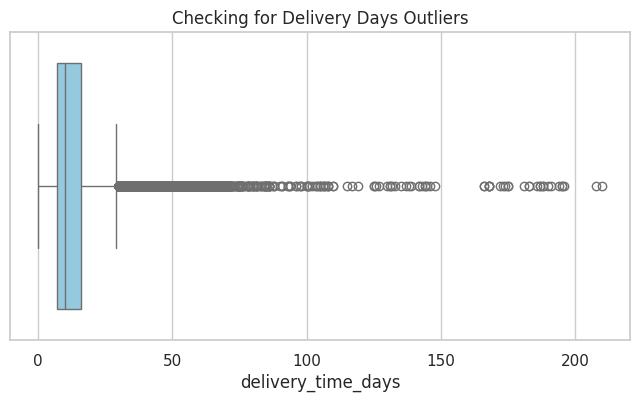

In [8]:
# Plot again, but this time i've used boxplot because i want to see more clear about outliers.

plt.figure(figsize = (8, 4))
sns.boxplot(x = df["delivery_time_days"], color ="skyblue")
plt.title("Checking for Delivery Days Outliers")
plt.show()

In [9]:
# Before we go more about data cleaning and outliers i want to check how this business going. First let's check who is the best five state.

state_sales = df.groupby("customer_state")["price"].sum().reset_index()

top_five_states = state_sales.sort_values(by = "price", ascending = False).head(5)

In [10]:
# Here is our best five state.

print(top_five_states)

   customer_state       price
25             SP  5066562.98
18             RJ  1759651.13
10             MG  1552481.83
22             RS   728718.47
17             PR   666063.51


/tmp/ipykernel_637/670245616.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_five_states, x = "customer_state", y = "price", palette = "magma")


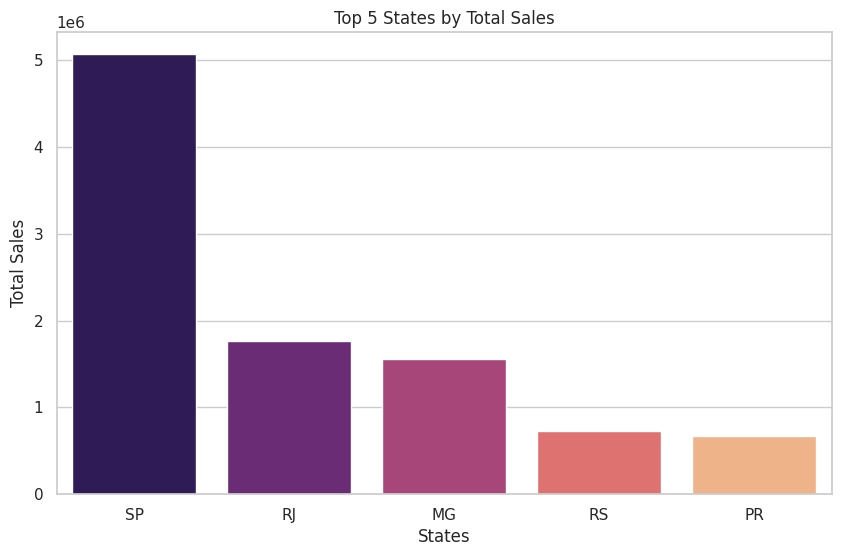

In [11]:
# Visualize it to see it more easier.

plt.figure(figsize = (10, 6))
sns.barplot(data = top_five_states, x = "customer_state", y = "price", palette = "magma")
plt.title("Top 5 States by Total Sales")
plt.xlabel("States")
plt.ylabel("Total Sales")
plt.show()

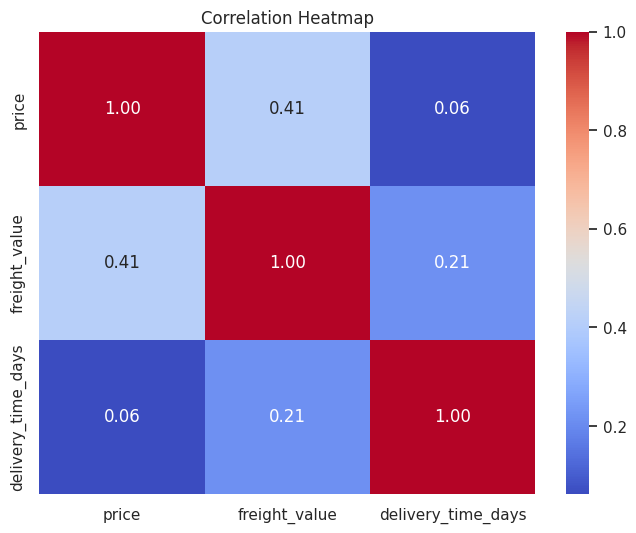

In [12]:
# After that i want to check correlation for some values first.

numeric_values = df[ ["price", "freight_value", "delivery_time_days"] ]

corr_matrix = numeric_values.corr()

plt.figure(figsize = (8, 6))
sns.heatmap(data = corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
# Now i want to check and handle outliers in evry numeric columns.

# Price column
Q1_p = df["price"].quantile(0.25)
Q3_p = df["price"].quantile(0.75)
IQR_p = Q3_p - Q1_p
limit_p = Q3_p + 1.5 * IQR_p

# Freight value column
Q1_f = df["freight_value"].quantile(0.25)
Q3_f = df["freight_value"].quantile(0.75)
IQR_f = Q3_f - Q1_f
limit_f = Q3_f + 1.5 * IQR_f

# Delivery time day column
Q1_d = df["delivery_time_days"].quantile(0.25)
Q3_d = df["delivery_time_days"].quantile(0.75)
IQR_d = Q3_d - Q1_d
limit_d = Q3_d + 1.5 * IQR_d

# I want create dataframe that does not have outliers value for seperate analyze.
df_mainstream = df[
    (df["price"] <= limit_p) &
    (df["freight_value"] <= limit_f) &
    (df["delivery_time_days"] <= limit_d)
].copy()

print(f"Original df have : {len(df)} rows.")
print(f"Mainstream df have : {len(df_mainstream)} rows.")

Original df have : 110189 rows.
Mainstream df have : 89832 rows.


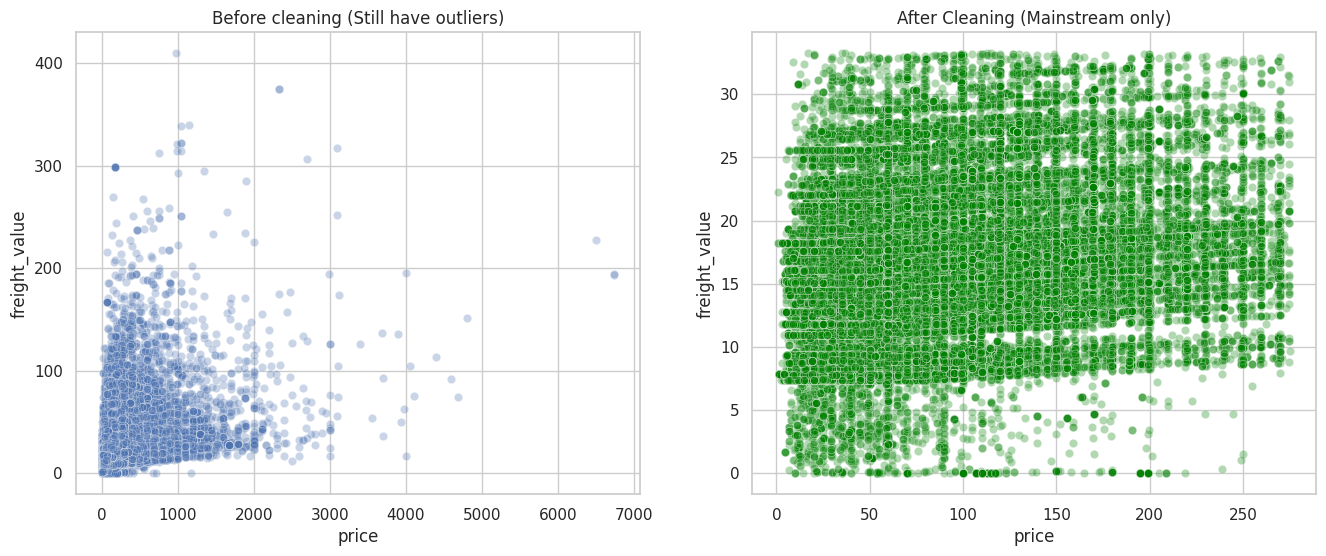

In [14]:
# After seperate the dataframe, now I will plot to see data again.

# Seperate to be left and right.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6))

# Plot the left side (Original df that still have outliers).
sns.scatterplot(data = df, x = "price", y = "freight_value", alpha = 0.3, ax = ax1)
ax1.set_title("Before cleaning (Still have outliers)")

# Plot the right side (The cleaned one).
sns.scatterplot(data = df_mainstream, x =  "price", y = "freight_value", alpha = 0.3, ax = ax2, color = "green")
ax2.set_title("After Cleaning (Mainstream only)")

plt.show()

In [15]:
# After see the chart, I want to know that what is the things that customers pay more than 5000 in price.

df[df["price"] > 5000]

,order_id,customer_id,order_status,purchase_at,delivered_at,customer_city,customer_state,product_category_name,price,freight_value,delivery_time_days
2593,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,delivered,2017-05-24 18:14:34+00:00,2017-06-05 17:09:48+00:00,marilia,SP,artes,6499.0,227.66,12
87215,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,delivered,2018-07-25 18:10:17+00:00,2018-08-15 14:57:50+00:00,vitoria,ES,pcs,6729.0,193.21,21
104434,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,delivered,2017-02-12 20:37:36+00:00,2017-03-03 14:23:18+00:00,campo grande,MS,utilidades_domesticas,6735.0,194.31,19


In [16]:
# Let's do EDA!

# I have three question that want to ckeck.
#   1. Which product catagory is the best sell?
#   2. What time that customer usually shopping?
#   3. How fast delivery for each state?

/tmp/ipykernel_637/2465799000.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_10_product_revenue, x = "price", y = "product_category_name", palette = "magma")


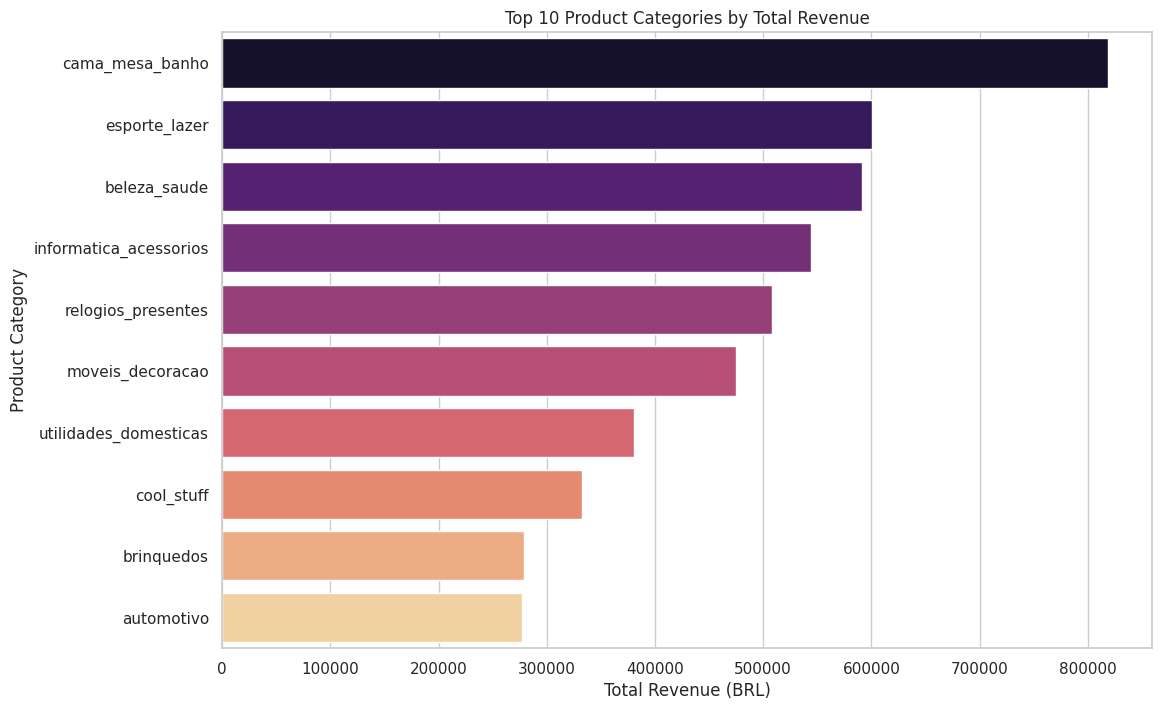

In [17]:
# 1. Which product catagory is the best sell?

category_analysis = df_mainstream.groupby("product_category_name").agg({
    "price" : "sum",
    "freight_value" : "mean"
}).reset_index()

top_10_product_revenue = category_analysis.sort_values(by = "price", ascending = False).head(10)

plt.figure(figsize = (12, 8))
sns.barplot(data = top_10_product_revenue, x = "price", y = "product_category_name", palette = "magma")

plt.title("Top 10 Product Categories by Total Revenue")
plt.xlabel("Total Revenue (BRL)")
plt.ylabel("Product Category")

plt.show()

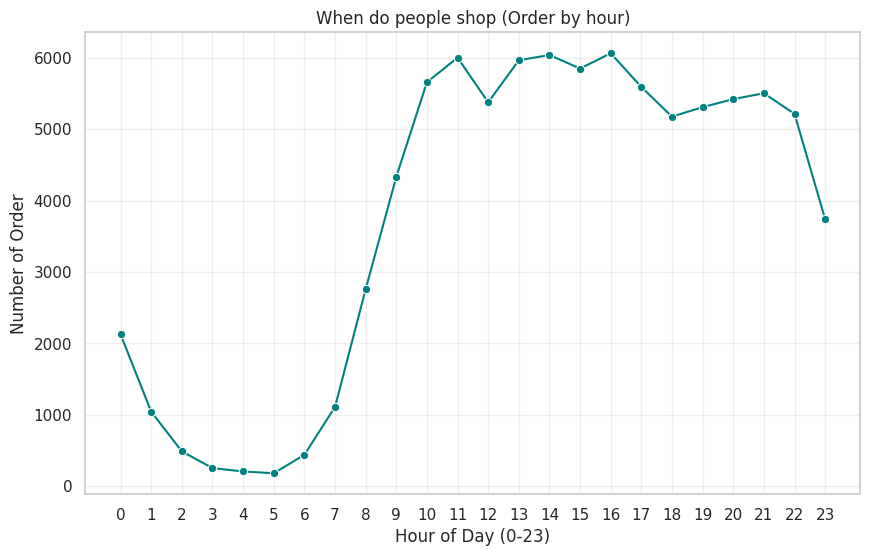

In [18]:
# 2. What time that customer usually shopping?

# Create new column for keep hour that customer purchase.
df_mainstream["purchase_hour"] = df_mainstream["purchase_at"].dt.hour

hourly_order = df_mainstream.groupby("purchase_hour").size().reset_index(name = "order_count")

plt.figure(figsize = (10, 6))
sns.lineplot(data = hourly_order, x = "purchase_hour", y = "order_count", marker = "o", color = "teal")

plt.title("When do people shop (Order by hour)")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Number of Order")
plt.xticks(range (0, 24))
plt.grid(True, alpha = 0.3)
plt.show()

/tmp/ipykernel_637/850671990.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = state_delivery, x = "customer_state", y = "delivery_time_days", palette = "coolwarm")


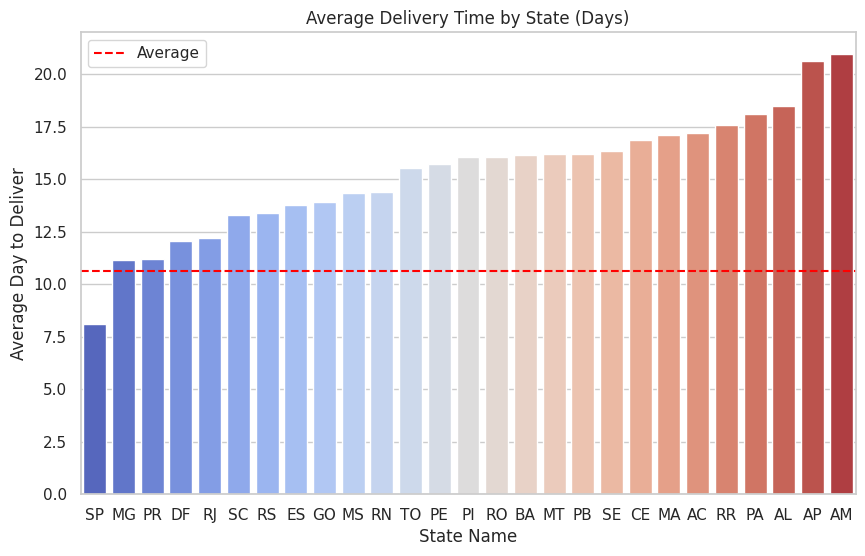

In [19]:
# 3. How fast delivery for each state?

# Find average delivery day for each state.
state_delivery = df_mainstream.groupby("customer_state")["delivery_time_days"].mean().reset_index()

# Sort values
state_delivery = state_delivery.sort_values(by = "delivery_time_days")

plt.figure(figsize = (10, 6))
sns.barplot(data = state_delivery, x = "customer_state", y = "delivery_time_days", palette = "coolwarm")

plt.title("Average Delivery Time by State (Days)")
plt.xlabel("State Name")
plt.ylabel("Average Day to Deliver")
plt.axhline(df_mainstream["delivery_time_days"].mean(), color = "red", linestyle = "--", label = "Average")
plt.legend()
plt.show()

In [20]:
# Prepare data to do visualization

df_mainstream.to_csv("olist_mainstream_data.csv", index = False)

from google.colab import files
files.download("olist_mainstream_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# After i've open visualization tool, i have found out that have missing values in product category columns. So i just want to make sure that how many rows that is a missing value.

null_count = df_mainstream["product_category_name"].isnull().sum()
total_rows = len(df_mainstream)

print(f"Null Count : {null_count} rows.")
print(f"Calculate as a {(null_count / total_rows) * 100 : .2f}% from all data.")

Null Count : 1328 rows.
Calculate as a  1.48% from all data.


In [22]:
# Fill na with "other"

df_mainstream["product_category_name"] = df_mainstream["product_category_name"].fillna("other")

In [23]:
# Recheck that stil hve missing values or not.

df_mainstream["product_category_name"].isnull().sum()

np.int64(0)

In [24]:
# Download data for visualization again.

df_mainstream.to_csv("olist_mainstream_data.csv", index = False)

from google.colab import files
files.download("olist_mainstream_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Machine Learning Part

In [25]:
# I want to practice my ML skills so i want to try it.
# For the ML, I want to predict how many days it will take to ship for each order, and the variable that i will use have 3 variable which is 1.customer state, 2. price, 3.freight value

ml_df = df_mainstream[ ["customer_state", "price", "freight_value", "delivery_time_days"] ] # delivery_time_days is a target variable.

ml_df = ml_df.dropna()

x = pd.get_dummies(ml_df.drop("delivery_time_days", axis = 1), drop_first = True)
y = ml_df["delivery_time_days"]

print("--- The Information is Ready ---")
print(f"The number of variables used for prediction (Features) : {x.shape[1]} variables")
print(f"Number of Order : {len(y)} rows.")

--- The Information is Ready ---
The number of variables used for prediction (Features) : 28 variables
Number of Order : 89832 rows.


In [26]:
# import library
from sklearn.model_selection import train_test_split

# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 63)

print(f"Total rows : {len(x)} rows")
print(f"Training set : {len(x_train)} rows")
print(f"Testing set : {len(x_test)} rows")

Total rows : 89832 rows
Training set : 71865 rows
Testing set : 17967 rows


In [27]:
# Train Model (I want to try Linear Regression and Random Forest)

# Import library
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Build and Train Liner Regression
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
lr_train_pred = lr_model.predict(x_train)
lr_test_pred = lr_model.predict(x_test)

# Build and Train Random Forest
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 63)
rf_model.fit(x_train, y_train)
rf_train_pred = rf_model.predict(x_train)
rf_test_pred = rf_model.predict(x_test)

# Show comparison results
print("--- Linear Regression Model Performance ---")
print(f"Train MAE : {mean_absolute_error(y_train, lr_train_pred) : .2f} days | Test MAE : {mean_absolute_error(y_test, lr_test_pred) : .2f} days")
print(f"Train R2 {r2_score(y_train, lr_train_pred) : .4f} | Test R2 : {r2_score(y_test, lr_test_pred) : .4f}")

print("---------------")

print("--- Random Forest Model Performance ---")
print(f"Train MAE : {mean_absolute_error(y_train, rf_train_pred) : .2f} days | Test MAE : {mean_absolute_error(y_test, rf_test_pred): .2f} days")
print(f"Train R2 : {r2_score(y_train, rf_train_pred) : .4f} | Test R2 : {r2_score(y_test, rf_test_pred): .4f}")

--- Linear Regression Model Performance ---
Train MAE :  4.13 days | Test MAE :  4.11 days
Train R2  0.2279 | Test R2 :  0.2172
---------------
--- Random Forest Model Performance ---
Train MAE :  2.15 days | Test MAE :  3.74 days
Train R2 :  0.7403 | Test R2 :  0.2790


In [27]:
# For the result of ML, i've seen that Random Forest is better than LR. Anyway the model is still overfitted and underfitted, so have to fix it later.